In [240]:
import qlat as q
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys

sys.path.insert(0,'/home/jhildebrand28/ktopipi/')
import corr_utils as cu

from corr_utils.jackknife import *

#from jackknife import *
#import corr_fit as cf
#from eff_mass import *
#import corr_utils as cu

In [241]:
importlib.reload(cu.diagrams)

<module 'corr_utils.diagrams' from '/home/jhildebrand28/ktopipi/corr_utils/diagrams.py'>

In [914]:
dst = "/home/jhildebrand28/ktopipi/results/16IH2/auto-contract-fsel-DV-test/"
#traj_list = list(range(2400,2501,10))
traj_list = [2000,2010,2020,3300,2030,2040]
corr_arr = cu.load_corr(dst,'pipi_vev.lat',traj_list)
print(corr_arr.shape)

['< 1 >  exprs[0]', '< wf_src(0) * pipi_i0(-tsep) >  exprs[1]', '< wf_snk(0) * pipi_i0^dag(0) >  exprs[2]', '< wf_src(1) * pipi_i0(-tsep) >  exprs[3]', '< wf_snk(1) * pipi_i0^dag(0) >  exprs[4]', '< wf_src(2) * pipi_i0(-tsep) >  exprs[5]', '< wf_snk(2) * pipi_i0^dag(0) >  exprs[6]', '< wf_src(3) * pipi_i0(-tsep) >  exprs[7]', '< wf_snk(3) * pipi_i0^dag(0) >  exprs[8]']
path: /home/jhildebrand28/ktopipi/results/16IH2/auto-contract-fsel-DV-test/ 
extension: pipi_vev.lat 
trajectory: 3300 
does not exist!

array shape: (5, 9, 32)
(5, 9, 32)
qassert: not qfile.null() from '../qlat_utils/lib/lat-io.cpp' line 163. (id_node=0 id_thread=0)
display_stack start
display_stack end


In [408]:
dst = "/home/jhildebrand28/ktopipi/results/16IH2/"

ld_meson_f = []
ld_meson_psel = []
for traj in range(1510,2011,10):
    #print(traj)
    ld_meson_f.append(q.load_lat_data(dst+f"auto-contract-CR-test/traj-{traj}/pipi_corr_psnk_psrc.lat").to_numpy())
    ld_meson_psel.append(q.load_lat_data(dst+f"auto-contract-CR-test/traj-{traj}/pipi_corr_psnk_psrc_psel.lat").to_numpy())

arr_f = np.array(ld_meson_f)
arr_psel = np.array(ld_meson_psel)

print(arr_f.shape)

(51, 33, 12)


In [409]:
ld_1 = q.load_lat_data(dst+f"auto-contract-CR-test/traj-1510/pipi_corr_psnk_psrc.lat")
ld_1.info()[0][2]

['< 1 >  exprs[0]',
 '< wf_snk(0) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[1]',
 '< wf_snk(0) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[2]',
 '< wf_snk(1) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[3]',
 '< wf_snk(1) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[4]',
 '< wf_snk(2) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[5]',
 '< wf_snk(2) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[6]',
 '< wf_snk(3) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[7]',
 '< wf_snk(3) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[8]',
 '< wf_snk(0) * wf_src(1) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[9]',
 '< wf_snk(0) * wf_src(1) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[10]',
 '< wf_snk(1) * wf_src(1) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[11]',
 '< wf_snk(1) * wf_src(1) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs

In [401]:
ld_fsel_test = q.load_lat_data(dst+f"auto-contract-CR-test/traj-1510/pipi_corr_psnk_psrc.lat")
ld_psel_test = q.load_lat_data(dst+f"auto-contract-CR-test/traj-1510/pipi_corr_psnk_psrc_psel.lat")
arr_fsel_test = ld_fsel_test.to_numpy()
arr_psel_test = ld_psel_test.to_numpy()
ld_fsel_test.info()[0][2]

['< 1 >  exprs[0]',
 '< wf_snk(0) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[1]',
 '< wf_snk(0) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[2]',
 '< wf_snk(1) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[3]',
 '< wf_snk(1) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[4]',
 '< wf_snk(2) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[5]',
 '< wf_snk(2) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[6]',
 '< wf_snk(3) * wf_src(0) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[7]',
 '< wf_snk(3) * wf_src(0) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[8]',
 '< wf_snk(0) * wf_src(1) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[9]',
 '< wf_snk(0) * wf_src(1) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs[10]',
 '< wf_snk(1) * wf_src(1) * pipi_i0^dag(0) * pipi_i0(-tsep) > (ADT4)  exprs[11]',
 '< wf_snk(1) * wf_src(1) * pipi_i20^dag(0) * pipi_i20(-tsep) > (ADT2)  exprs

In [546]:
ld_fsel_CR1 = []
ld_fsel_CR2 = []
ld_fsel_CR3 = []
ld_psel_CR = []

#traj 1080 has I=2 data, 1300 has I=0 data. 

#ld_fsel_DC.append(q.load_lat_data(dst+f"auto-contract-fsel-test/traj-1300/pipi_corr_psnk_psrc.lat"))
#ld_psel_DC.append(q.load_lat_data(dst+f"auto-contract-fsel-test/traj-1300/pipi_corr_psnk_psrc_psel.lat"))

for traj in range(1510,1701,10):
    ld_fsel_CR1.append(q.load_lat_data(dst+f"auto-contract-CR-test/traj-{traj}/pipi_corr_psnk_psrc.lat"))
    ld_fsel_CR2.append(q.load_lat_data(dst+f"auto-contract-CR2-test/traj-{traj}/pipi_corr_psnk_psrc.lat"))
    ld_fsel_CR3.append(q.load_lat_data(dst+f"auto-contract-CR3-test/traj-{traj}/pipi_corr_psnk_psrc.lat"))
    ld_psel_CR.append(q.load_lat_data(dst+f"auto-contract-CR-test/traj-{traj}/pipi_corr_psnk_psrc_psel.lat"))

arr_fsel_CR1 = np.array(ld_fsel_CR1)
arr_fsel_CR2 = np.array(ld_fsel_CR2)
arr_fsel_CR3 = np.array(ld_fsel_CR3)
arr_psel_CR = np.array(ld_psel_CR)

print(arr_fsel_CR3.shape)

(20, 33, 12)


In [156]:
ld_psel_D = []
ld_psel_V = []
ld_psel_meson = []

for traj in range(2000,2241,10):
    print(traj)
    ld_psel_meson.append(q.load_lat_data(dst+f"auto-contract-fsel-DV-test/traj-{traj}/meson_corr_psnk_psrc_psel.lat"))
    ld_psel_D.append(q.load_lat_data(dst+f"auto-contract-fsel-DV-test/traj-{traj}/pipi_corr_psnk_psrc_psel.lat"))
    ld_psel_V.append(q.load_lat_data(dst+f"auto-contract-fsel-DV-test/traj-{traj}/pipi_vev.lat"))

arr_psel_D = np.array(ld_psel_D)
arr_psel_V = np.array(ld_psel_V)
arr_psel_meson = np.array(ld_psel_meson)

print(arr_psel_meson.shape)


2000
qassert: not qfile.null() from '../qlat_utils/lib/lat-io.cpp' line 163. (id_node=0 id_thread=0)
display_stack start
display_stack end


RuntimeError: Unknown exception

In [829]:
ld_fsel_D = []
ld_fsel_V = []
ld_psel = []


#traj 1080 has I=2 data, 1300 has I=0 data. 

#ld_fsel_DC.append(q.load_lat_data(dst+f"auto-contract-fsel-test/traj-1300/pipi_corr_psnk_psrc.lat"))
#ld_psel_DC.append(q.load_lat_data(dst+f"auto-contract-fsel-test/traj-1300/pipi_corr_psnk_psrc_psel.lat"))

for traj in range(3070,3191,10):
    ld_fsel_D.append(q.load_lat_data(dst+f"auto-contract-fsel-DV-test/traj-{traj}/meson_corr_psnk_psrc_D.lat"))
    ld_fsel_V.append(q.load_lat_data(dst+f"auto-contract-fsel-DV-test/traj-{traj}/pipi_vev.lat"))
    ld_psel.append(q.load_lat_data(dst+f"auto-contract-fsel-DV-test/traj-{traj}/pipi_corr_psnk_psrc_psel.lat"))

arr_fsel_D = np.array(ld_fsel_D)
arr_fsel_V = np.array(ld_fsel_V)
arr_psel = np.array(ld_psel)

print(arr_fsel_D.shape)

(13, 37, 32, 32)


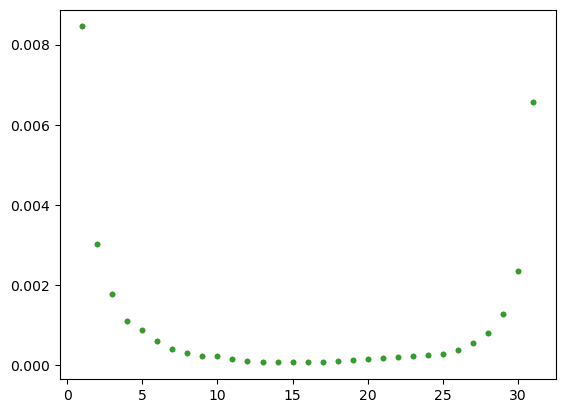

In [578]:
ts = np.linspace(1,31,31)
fig, ax = plt.subplots()
ax.plot(ts, arr_fsel_D[0,1,1:,0], marker='.', ls='')
ax.plot(ts, arr_fsel_D[0,6,1:,0], marker='.', ls='')
ax.plot(ts, arr_fsel_D[0,8,1:,0], marker='.', ls='')

In [9]:
t_size = 32
Delta = 1

## Single pion correlation function

In [410]:
arr_f_jk = jackblocks_all(arr_f, omit=[])
arr_psel_jk = jackblocks_all(arr_psel, omit=[])

arr_f_norm = counter_norm(arr_f_jk)
arr_psel_norm = counter_norm(arr_psel_jk)

arr_f_avg, arr_f_err = jack_all(arr_f_norm.real)
arr_psel_avg, arr_psel_err = jack_all(arr_psel_norm.real)

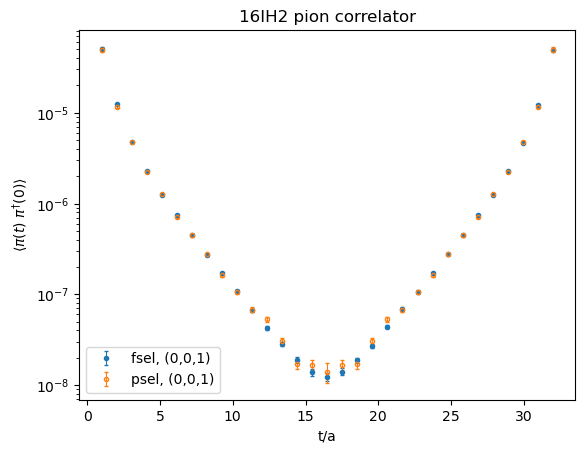

In [237]:
tt = np.linspace(1,32,31)
fig,ax = plt.subplots()
#ax.errorbar(tt, arr_f_avg[0,1:], yerr=arr_f_err[0,1:],marker='.',ls='',elinewidth=0.8, capsize=1.5,label='fsel, (0,0,0)')
#ax.errorbar(tt, arr_psel_avg[0,1:], yerr=arr_psel_err[0,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8, capsize=1.5,label='psel, (0,0,0)')

ax.errorbar(tt, arr_f_avg[1,1:], yerr=arr_f_err[1,1:],marker='.',ls='',elinewidth=0.8, capsize=1.5,label='fsel, (0,0,1)')
ax.errorbar(tt, arr_psel_avg[1,1:], yerr=arr_psel_err[1,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8, capsize=1.5,label='psel, (0,0,1)')

#ax.errorbar(tt, arr_f_avg[2,1:], yerr=arr_f_err[2,1:],marker='.',ls='',elinewidth=0.8, capsize=1.5,label='fsel, (0,1,1)')
#ax.errorbar(tt, arr_psel_avg[2,1:], yerr=arr_psel_err[2,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8, capsize=1.5,label='psel, (0,1,1)')

#ax.errorbar(tt, arr_f_avg[3,1:], yerr=arr_f_err[3,1:],marker='.',ls='',elinewidth=0.8, capsize=1.5,label='fsel, (1,1,1)')
#ax.errorbar(tt, arr_psel_avg[3,1:], yerr=arr_psel_err[3,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8, capsize=1.5,label='psel, (1,1,1)')

ax.set_xlabel('t/a')
ax.set_ylabel(r'$\langle \pi(t) \ \pi^{\dagger}(0) \rangle$')
ax.set_title("16IH2 pion correlator")
ax.set_yscale('log')
ax.legend();

In [238]:
em_000_fsel = eff_mass_2d_cosh(arr_f_norm[:,0,:].real)
em_001_fsel = eff_mass_2d_cosh(arr_f_norm[:,1,:].real)
em_011_fsel = eff_mass_2d_ln(arr_f_norm[:,2,:].real)
em_111_fsel = eff_mass_2d_ln(arr_f_norm[:,3,:].real)

em_fsel = np.stack([em_000_fsel,em_001_fsel,em_011_fsel,em_111_fsel],axis=1)

em_000_psel = eff_mass_2d_cosh(arr_psel_norm[:,0,:].real)
em_001_psel = eff_mass_2d_cosh(arr_psel_norm[:,1,:].real)
em_011_psel = eff_mass_2d_ln(arr_psel_norm[:,2,:].real)
em_111_psel = eff_mass_2d_ln(arr_psel_norm[:,3,:].real)

em_psel = np.stack([em_000_psel,em_001_psel,em_011_psel,em_111_psel],axis=1)

em_fsel_avg, em_fsel_err = jack_all(em_fsel.real)
em_psel_avg, em_psel_err = jack_all(em_psel.real)

In [217]:
em_fsel_avg.shape

(4, 14)

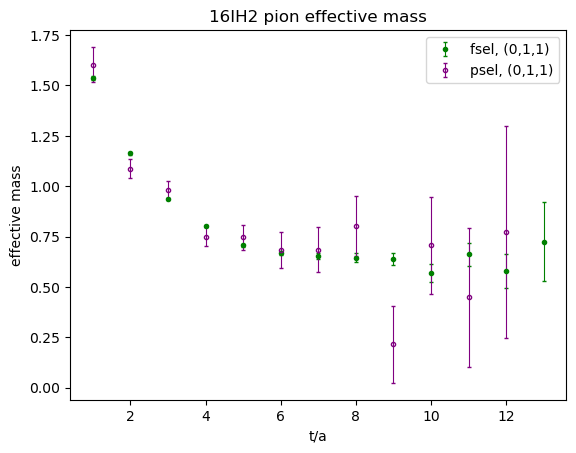

In [270]:
th = np.linspace(1,13,13)
fig, ax = plt.subplots()
#ax.errorbar(th, em_fsel_avg[0,1:], yerr=em_fsel_err[0,1:] ,marker='.',ls='', color='green', elinewidth=0.8, capsize=1.5,label='fsel, (0,0,0)')
#ax.errorbar(th, em_psel_avg[0,1:], yerr=em_psel_err[0,1:] ,marker='.',markerfacecolor='none',ls='', color='purple', elinewidth=0.8, capsize=1.5,label='psel, (0,0,0)')

#ax.errorbar(th, em_fsel_avg[1,1:], yerr=em_fsel_err[1,1:] ,marker='.',ls='', color='green', elinewidth=0.8, capsize=1.5,label='fsel, (0,0,1)')
#ax.errorbar(th, em_psel_avg[1,1:], yerr=em_psel_err[1,1:] ,marker='.',markerfacecolor='none',ls='', color='purple', elinewidth=0.8, capsize=1.5,label='psel, (0,0,1)')

ax.errorbar(th, em_fsel_avg[2,1:], yerr=em_fsel_err[2,1:] ,marker='.',ls='', color='green', elinewidth=0.8, capsize=1.5,label='fsel, (0,1,1)')
ax.errorbar(th, em_psel_avg[2,1:], yerr=em_psel_err[2,1:] ,marker='.',markerfacecolor='none',ls='', color='purple', elinewidth=0.8, capsize=1.5,label='psel, (0,1,1)')

#ax.errorbar(th, em_fsel_avg[3,1:], yerr=em_fsel_err[3,1:] ,marker='.',ls='', color='green', elinewidth=0.8, capsize=1.5,label='fsel, (1,1,1)')
#ax.errorbar(th, em_psel_avg[3,1:], yerr=em_psel_err[3,1:] ,marker='.',markerfacecolor='none',ls='', color='purple', elinewidth=0.8, capsize=1.5,label='psel, (1,1,1)')

#ax.set_ylim(0,2.5)

ax.set_xlabel('t/a')
ax.set_ylabel('effective mass')
ax.set_title("16IH2 pion effective mass")
ax.legend();

In [129]:
E0_000_fsel, E0_000_fsel_err = cf.meson_energy_1state(arr_f_norm[:,0,:].real,5,12,shrinkage=0.05)

Covariance matrix condition number: 719.1306603596921


In [280]:
E0_000_fsel, E0_000_fsel_err = cf.meson_energy_1state(arr_f_norm[:,0,:].real,5,12,fit_model=two_exp,shrinkage=0.05)
E0_000_psel, E0_000_psel_err = cf.meson_energy_1state(arr_psel_norm[:,0,:].real,5,12,fit_model=two_exp,shrinkage=0.05)

E0_001_fsel, E0_001_fsel_err = cf.meson_energy_1state(arr_f_norm[:,1,:].real,5,12,two_exp,shrinkage=0.05)
E0_001_psel, E0_001_psel_err = cf.meson_energy_1state(arr_psel_norm[:,1,:].real,5,12,two_exp,shrinkage=0.05)

E0_011_fsel, E0_011_fsel_err = cf.meson_energy_1state(arr_f_norm[:,2,:].real,5,12,two_exp,shrinkage=0.05)
E0_011_psel, E0_011_psel_err = cf.meson_energy_1state(arr_psel_norm[:,2,:].real,5,12,two_exp,shrinkage=0.05)

E0_111_fsel, E0_111_fsel_err = cf.meson_energy_1state(arr_f_norm[:,3,:].real,5,10,two_exp,shrinkage=0.05)
E0_111_psel, E0_111_psel_err = cf.meson_energy_1state(arr_psel_norm[:,3,:].real,5,10,two_exp,shrinkage=0.05)

Covariance matrix condition number: 752.1373780528081
Covariance matrix condition number: 618.3185364278369
Covariance matrix condition number: 1093.9292433735582
Covariance matrix condition number: 289.7399339776236
Covariance matrix condition number: 442.47173799199066
Covariance matrix condition number: 140.53275517901807
Covariance matrix condition number: 57.51431733494659
Covariance matrix condition number: 65.29820339264177


In [262]:
E0_000_fsel_2st, E0_000_fsel_err_2st, E1_000_fsel, E1_000_fsel_err = cf.meson_energy_2state(arr_f_norm[:,0,:].real, 5,12,shrinkage=0.05)
E0_001_fsel_2st, E0_001_fsel_err_2st, E1_001_fsel, E1_001_fsel_err = cf.meson_energy_2state(arr_f_norm[:,1,:].real, 5,12,shrinkage=0.05)
#E0_011_fsel_2st, E0_011_fsel_err_2st, E1_011_fsel, E1_011_fsel_err = cf.meson_energy_2state(arr_f_norm[:,2,:].real, 5,12,shrinkage=0.5)
#E0_111_fsel_2st, E0_111_fsel_err_2st, E1_111_fsel, E1_111_fsel_err = cf.meson_energy_2state(arr_f_norm[:,3,:].real, 5,12)

Covariance matrix condition number: 752.1373780528081
0.26220577897383995
Covariance matrix condition number: 1093.9292433735582
0.5257109272064165
Covariance matrix condition number: 172.5418914126428
0.7026012879139242


In [130]:
print(f"{E0_000_fsel} +/- {E0_000_fsel_err}")

0.2516081566315924 +/- 0.0019554110794776343


In [281]:
print(f"fsel 000 pion energy, 1 state fit: {E0_000_fsel} +/- {E0_000_fsel_err}")
print(f"fsel 000 pion energy, 2 state fit: {E0_000_fsel_2st} +/- {E0_000_fsel_err_2st}")
print(f"psel 000 pion energy, 1 state fit: {E0_000_psel} +/- {E0_000_psel_err}")

print(f"\nfsel 001 pion energy, 1 state fit: {E0_001_fsel} +/- {E0_001_fsel_err}")
print(f"fsel 001 pion energy, 2 state fit: {E0_001_fsel_2st} +/- {E0_001_fsel_err_2st}")
print(f"psel 001 pion energy, 1 state fit: {E0_001_psel} +/- {E0_001_psel_err}")

print(f"\nfsel 011 pion energy, 1 state fit: {E0_011_fsel} +/- {E0_011_fsel_err}")
#print(f"fsel 011 pion energy, 2 state fit: {E0_011_fsel_2st} +/- {E0_011_fsel_err_2st}")
print(f"psel 011 pion energy, 1 state fit: {E0_011_psel} +/- {E0_011_psel_err}")

print(f"\nfsel 111 pion energy: {E0_111_fsel} +/- {E0_111_fsel_err}")
print(f"psel 111 pion energy: {E0_111_psel} +/- {E0_111_psel_err}")

fsel 000 pion energy, 1 state fit: 0.25054978385197735 +/- 0.0014010340089326866
fsel 000 pion energy, 2 state fit: 0.24414342723745455 +/- 0.002365182848178927
psel 000 pion energy, 1 state fit: 0.25137518371539413 +/- 0.001638013146941303

fsel 001 pion energy, 1 state fit: 0.5007341764505041 +/- 0.004695262702916197
fsel 001 pion energy, 2 state fit: 0.46439805646305504 +/- 0.013710750864126535
psel 001 pion energy, 1 state fit: 0.4852183345037015 +/- 0.009557502489404665

fsel 011 pion energy, 1 state fit: 0.6838966251608797 +/- 0.008104207395955845
psel 011 pion energy, 1 state fit: 0.6671613853980128 +/- 0.029756289944612158

fsel 111 pion energy: 0.826967729086919 +/- 0.01558452619557492
psel 111 pion energy: 0.7691769530799398 +/- 0.06533485253971608


In [282]:
E_000_diff = np.abs(E0_000_fsel_2st - E0_000_fsel)
E_001_diff = np.abs(E0_001_fsel_2st - E0_001_fsel)
#E_011_diff = np.abs(E0_011_fsel_2st - E0_011_fsel)

print(f"Difference in ground state pion energy from 2 state and 1 state fit: {E_000_diff}")
print(f"Difference in 001 pion energy from 2 state and 1 state fit: {E_001_diff}")
#print(f"Difference in 011 pion energy from 2 state and 1 state fit: {E_011_diff}")

Difference in ground state pion energy from 2 state and 1 state fit: 0.006406356614522796
Difference in 001 pion energy from 2 state and 1 state fit: 0.03633611998744907


In [283]:
print(f"fsel data 000 pion energy: {E0_000_fsel:.4f}(14)(64)")
print(f"fsel data 001 pion energy: {E0_001_fsel:.4f}(47)(363)")
print(f"fsel data 011 pion energy: {E0_011_fsel:.4f}(81)(52)")
print(f"fsel data 111 pion energy: {E0_111_fsel:.3f}(16)")

fsel data 000 pion energy: 0.2505(14)(64)
fsel data 001 pion energy: 0.5007(47)(363)
fsel data 011 pion energy: 0.6839(81)(52)
fsel data 111 pion energy: 0.827(16)


## Two pion two point functions

### Cross and Rectangle diagrams

In [382]:
#DC_norm = np.divide(arr_DC, arr_DC[0], where=arr_DC[0]>0)
#RV_norm = np.divide(arr_RV, arr_RV[0], where=arr_RV[0]>0)
fsel_norm = np.divide(arr_fsel_test, arr_fsel_test[0], where=arr_fsel_test[0]>0)
psel_norm = np.divide(arr_psel_test, arr_psel_test[0], where=arr_psel_test[0]>0)
print(psel_norm.shape)

(5, 12)


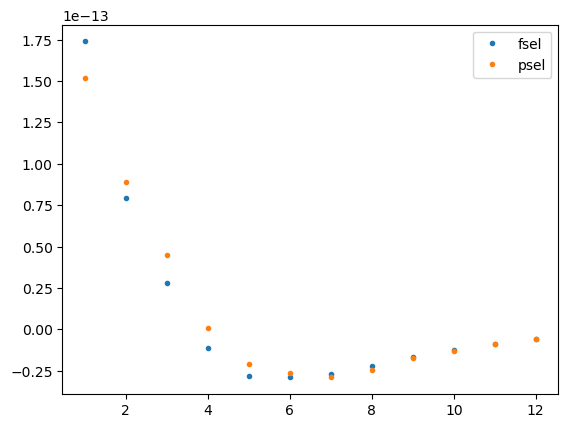

In [413]:
ts = np.linspace(1,12,12)
fig, ax = plt.subplots()
#ax.plot(ts, DC_norm[2], marker='.', ls='',label='fsel')

#ax.plot(ts, arr_f_avg[2].real, marker='.', ls='',label='fsel')
#ax.plot(ts, arr_psel_avg[2].real, marker='.', ls='',label='psel')

#ax.plot(ts, psel_norm[2].real, marker='.', ls='',label='psel, C')
#ax.plot(ts, psel_norm[3].real, marker='.', ls='',label='psel. R')

#ax.plot(ts, psel_norm[27].real, marker='.', ls='',label='psel, C')
#ax.plot(ts, psel_norm[28].real, marker='.', ls='',label='psel. R')

#ax.plot(ts, psel_norm[52].real, marker='.', ls='',label='psel, C')
#ax.plot(ts, psel_norm[53].real, marker='.', ls='',label='psel. R')

#ax.plot(ts, psel_norm[77].real, marker='.', ls='',label='psel, C')
#ax.plot(ts, psel_norm[78].real, marker='.', ls='',label='psel. R')

#ax.set_yscale("log")
ax.legend()

In [547]:
fsel_CR1_jks = jackblocks_all(arr_fsel_CR1,omit=[])
fsel_CR2_jks = jackblocks_all(arr_fsel_CR2,omit=[])
fsel_CR3_jks = jackblocks_all(arr_fsel_CR3,omit=[])
psel_CR_jks = jackblocks_all(arr_psel_CR,omit=[])

#fsel_CR_tot_jks = jackblocks_all(arr_fsel_CR1 + arr_fsel_CR2,omit=[])
fsel_CR12_jks = fsel_CR1_jks + fsel_CR2_jks
fsel_CR_tot_jks = fsel_CR1_jks + fsel_CR2_jks + fsel_CR3_jks

fsel_CR1_norm = counter_norm(fsel_CR1_jks)
fsel_CR12_norm = counter_norm(fsel_CR12_jks)
fsel_CR_norm = counter_norm(fsel_CR_tot_jks)
psel_CR_norm = counter_norm(psel_CR_jks)

fsel_CR1_avg, fsel_CR1_err = jack_all(fsel_CR1_norm.real)
fsel_CR12_avg, fsel_CR12_err = jack_all(fsel_CR1_norm.real)
fsel_CR_avg, fsel_CR_err = jack_all(fsel_CR_norm.real)
psel_CR_avg, psel_CR_err = jack_all(psel_CR_norm.real)

print(fsel_CR_norm.shape)
print(fsel_CR_avg.shape)

(20, 32, 12)
(32, 12)


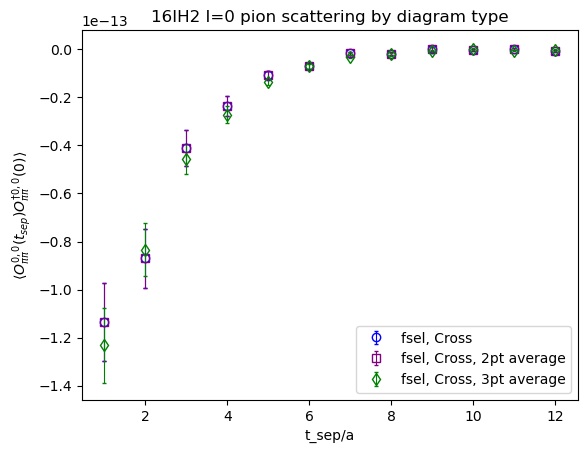

In [561]:
fig, ax = plt.subplots()

ax.errorbar(ts, fsel_CR1_avg[31], yerr=fsel_CR1_err[31],marker='o', markersize='6', markerfacecolor='none',markeredgecolor='blue',ls='',elinewidth=0.8,capsize=1.5,color='blue',label='fsel, Cross')
ax.errorbar(ts, fsel_CR12_avg[31], yerr=fsel_CR12_err[31],marker='s', markersize='6',markerfacecolor='none',markeredgecolor='purple',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='fsel, Cross, 2pt average')
ax.errorbar(ts, fsel_CR_avg[31], yerr=fsel_CR_err[31],marker='d', markersize='6',markerfacecolor='none',markeredgecolor='green',ls='',elinewidth=0.8,capsize=1.5,color='green',label='fsel, Cross, 3pt average')
#ax.errorbar(ts, psel_CR_avg[30], yerr=psel_CR_err[30],marker='.',ls='',elinewidth=0.8,capsize=1.5,color='green',label='psel, Cross')

#ax.errorbar(ts, fsel_CR_avg[1], yerr=fsel_CR_err[1],marker='.', markerfacecolor='none',markeredgecolor='purple',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='fsel, (0,0,0), Rectangle')
#ax.errorbar(ts, psel_CR_avg[1], yerr=psel_CR_err[1],marker='.',ls='',elinewidth=0.8,capsize=1.5,color='green',label='psel, (0,0,0), Rectangle')

#ax.errorbar(ts, fsel_CR_avg[11], yerr=fsel_CR_err[11],marker='.', markerfacecolor='none',markeredgecolor='purple',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='fsel, (0,0,1), Cross')
#ax.errorbar(ts, psel_CR_avg[11], yerr=psel_CR_err[11],marker='.',ls='',elinewidth=0.8,capsize=1.5,color='green',label='psel, (0,0,1), Cross')

#ax.errorbar(ts, fsel_CR_avg[20], yerr=fsel_CR_err[20],marker='.', markerfacecolor='none',markeredgecolor='purple',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='fsel, (0,0,1), Rectangle')
#ax.errorbar(ts, psel_CR_avg[20], yerr=psel_CR_err[20],marker='.',ls='',elinewidth=0.8,capsize=1.5,color='green',label='psel, (0,0,1), Rectangle')

ax.set_xlabel('t_sep/a')
ax.set_ylabel(r'$\langle O^{0,0}_{\pi\pi}(t_{sep}) O^{\dagger 0,0}_{\pi\pi}(0)\rangle$')
ax.set_title("16IH2 I=0 pion scattering by diagram type")
#ax.set_yscale('log')
ax.legend();

In [564]:
E0_C_000_fsel, E0_C_000_fsel_err = cf.meson_energy_1state(fsel_CR_norm[:,0,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C_001_fsel, E0_C_001_fsel_err = cf.meson_energy_1state(-fsel_CR_norm[:,10,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C_011_fsel, E0_C_011_fsel_err = cf.meson_energy_1state(fsel_CR_norm[:,20,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C_111_fsel, E0_C_111_fsel_err = cf.meson_energy_1state(fsel_CR_norm[:,30,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)

E0_C1_000_fsel, E0_C1_000_fsel_err = cf.meson_energy_1state(fsel_CR1_norm[:,0,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C1_001_fsel, E0_C1_001_fsel_err = cf.meson_energy_1state(-fsel_CR1_norm[:,10,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C1_011_fsel, E0_C1_011_fsel_err = cf.meson_energy_1state(fsel_CR1_norm[:,20,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C1_111_fsel, E0_C1_111_fsel_err = cf.meson_energy_1state(fsel_CR1_norm[:,30,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)

E0_C12_000_fsel, E0_C12_000_fsel_err = cf.meson_energy_1state(fsel_CR12_norm[:,0,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C12_001_fsel, E0_C12_001_fsel_err = cf.meson_energy_1state(-fsel_CR12_norm[:,10,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C12_011_fsel, E0_C12_011_fsel_err = cf.meson_energy_1state(fsel_CR12_norm[:,20,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C12_111_fsel, E0_C12_111_fsel_err = cf.meson_energy_1state(fsel_CR12_norm[:,30,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)

E0_C_000_psel, E0_C_000_psel_err = cf.meson_energy_1state(psel_CR_norm[:,0,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C_001_psel, E0_C_001_psel_err = cf.meson_energy_1state(-psel_CR_norm[:,10,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C_011_psel, E0_C_011_psel_err = cf.meson_energy_1state(psel_CR_norm[:,20,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)
E0_C_111_psel, E0_C_111_psel_err = cf.meson_energy_1state(psel_CR_norm[:,30,:].real,2,10,fit_model=pure_exp,shrinkage=1.0)

E0_R_000_fsel, E0_R_000_fsel_err = cf.meson_energy_1state(fsel_CR_norm[:,1,:].real,1,11,fit_model=pure_exp,shrinkage=1.0)
E0_R_001_fsel, E0_R_001_fsel_err = cf.meson_energy_1state(-fsel_CR_norm[:,11,:].real,3,10,fit_model=pure_exp,shrinkage=1.0)
E0_R_011_fsel, E0_R_011_fsel_err = cf.meson_energy_1state(fsel_CR_norm[:,21,:].real,1,8,fit_model=pure_exp,shrinkage=1.0)
E0_R_111_fsel, E0_R_111_fsel_err = cf.meson_energy_1state(fsel_CR_norm[:,31,:].real,1,10,fit_model=pure_exp,shrinkage=1.0)

E0_R1_000_fsel, E0_R1_000_fsel_err = cf.meson_energy_1state(fsel_CR1_norm[:,1,:].real,1,11,fit_model=pure_exp,shrinkage=1.0)
E0_R1_001_fsel, E0_R1_001_fsel_err = cf.meson_energy_1state(-fsel_CR1_norm[:,11,:].real,3,10,fit_model=pure_exp,shrinkage=1.0)
E0_R1_011_fsel, E0_R1_011_fsel_err = cf.meson_energy_1state(fsel_CR1_norm[:,21,:].real,1,8,fit_model=pure_exp,shrinkage=1.0)
E0_R1_111_fsel, E0_R1_111_fsel_err = cf.meson_energy_1state(fsel_CR1_norm[:,31,:].real,1,10,fit_model=pure_exp,shrinkage=1.0)

E0_R12_000_fsel, E0_R12_000_fsel_err = cf.meson_energy_1state(fsel_CR12_norm[:,1,:].real,1,11,fit_model=pure_exp,shrinkage=1.0)
E0_R12_001_fsel, E0_R12_001_fsel_err = cf.meson_energy_1state(-fsel_CR12_norm[:,11,:].real,3,10,fit_model=pure_exp,shrinkage=1.0)
E0_R12_011_fsel, E0_R12_011_fsel_err = cf.meson_energy_1state(fsel_CR12_norm[:,21,:].real,1,8,fit_model=pure_exp,shrinkage=1.0)
E0_R12_111_fsel, E0_R12_111_fsel_err = cf.meson_energy_1state(fsel_CR12_norm[:,31,:].real,1,10,fit_model=pure_exp,shrinkage=1.0)

E0_R_000_psel, E0_R_000_psel_err = cf.meson_energy_1state(psel_CR_norm[:,1,:].real,1,11,fit_model=pure_exp,shrinkage=1.0)
E0_R_001_psel, E0_R_001_psel_err = cf.meson_energy_1state(-psel_CR_norm[:,11,:].real,3,10,fit_model=pure_exp,shrinkage=1.0)
E0_R_011_psel, E0_R_011_psel_err = cf.meson_energy_1state(psel_CR_norm[:,21,:].real,1,8,fit_model=pure_exp,shrinkage=1.0)
#E0_R_111_psel, E0_R_111_psel_err = cf.meson_energy_1state(psel_CR_norm[:,31,:].real,3,10,fit_model=pure_exp,shrinkage=1.0)

Covariance matrix condition number: 616.6528683771343
Covariance matrix condition number: 333.7000029758361
Covariance matrix condition number: 881.9704127062994
Covariance matrix condition number: 1192.432107140168
Covariance matrix condition number: 578.5774682648469
Covariance matrix condition number: 542.4812388876262
Covariance matrix condition number: 1454.1989935072927
Covariance matrix condition number: 1228.6603685788436
Covariance matrix condition number: 502.3481743548677
Covariance matrix condition number: 404.9208754324825
Covariance matrix condition number: 787.0591938863298
Covariance matrix condition number: 1242.4428114124594
Covariance matrix condition number: 477.5135899438712
Covariance matrix condition number: 198.41972825178308
Covariance matrix condition number: 534.7280392069988
Covariance matrix condition number: 547.5033508565256
Covariance matrix condition number: 1348.0638729268255
Covariance matrix condition number: 54.48771940431633
Covariance matrix condi

In [567]:
print(f"fsel 3pt avg 000 C diagram exponential fit: {E0_C_000_fsel} +/- {E0_C_000_fsel_err}")
print(f"fsel 2pt avg 000 C diagram exponential fit: {E0_C12_000_fsel} +/- {E0_C12_000_fsel_err}")
print(f"fsel 1pt avg 000 C diagram exponential fit: {E0_C1_000_fsel} +/- {E0_C1_000_fsel_err}")
print(f"psel 000 C diagram exponential fit: {E0_C_000_psel} +/- {E0_C_000_psel_err}")

print(f"\nfsel 3pt avg 001 C diagram exponential fit: {E0_C_001_fsel} +/- {E0_C_001_fsel_err}")
print(f"fsel 2pt avg 001 C diagram exponential fit: {E0_C12_001_fsel} +/- {E0_C12_001_fsel_err}")
print(f"fsel 1pt avg 001 C diagram exponential fit: {E0_C1_001_fsel} +/- {E0_C1_001_fsel_err}")
print(f"psel 001 C diagram exponential fit: {E0_C_001_psel} +/- {E0_C_001_psel_err}")

print(f"\nfsel 3pt avg 011 C diagram exponential fit: {E0_C_011_fsel} +/- {E0_C_011_fsel_err}")
print(f"fsel 2pt avg 011 C diagram exponential fit: {E0_C12_011_fsel} +/- {E0_C12_011_fsel_err}")
print(f"fsel 1pt avg 011 C diagram exponential fit: {E0_C1_011_fsel} +/- {E0_C1_011_fsel_err}")
print(f"psel 011 C diagram exponential fit: {E0_C_011_psel} +/- {E0_C_011_psel_err}")

print(f"\nfsel 3pt avg 111 C diagram exponential fit: {E0_C_111_fsel} +/- {E0_C_111_fsel_err}")
print(f"fsel 2pt avg 111 C diagram exponential fit: {E0_C12_111_fsel} +/- {E0_C12_111_fsel_err}")
print(f"fsel 1pt avg 111 C diagram exponential fit: {E0_C1_111_fsel} +/- {E0_C1_111_fsel_err}")
print(f"psel 111 C diagram exponential fit: {E0_C_111_psel} +/- {E0_C_111_psel_err}")

fsel 3pt avg 000 C diagram exponential fit: 0.375004938777697 +/- 0.008569926249013274
fsel 2pt avg 000 C diagram exponential fit: 0.3749366321269644 +/- 0.007727090332198437
fsel 1pt avg 000 C diagram exponential fit: 0.37435926101757816 +/- 0.007864705730609057
psel 000 C diagram exponential fit: 0.37124965238934654 +/- 0.009618606908902533

fsel 3pt avg 001 C diagram exponential fit: 0.6777349181473407 +/- 0.03007100460694593
fsel 2pt avg 001 C diagram exponential fit: 0.6813338945413998 +/- 0.026924260933088508
fsel 1pt avg 001 C diagram exponential fit: 0.701840527313181 +/- 0.03932027277146712
psel 001 C diagram exponential fit: 0.675633957219246 +/- 0.06383636940093437

fsel 3pt avg 011 C diagram exponential fit: 0.40868475558065687 +/- 0.010652836980296829
fsel 2pt avg 011 C diagram exponential fit: 0.40789057643123133 +/- 0.009550533302149526
fsel 1pt avg 011 C diagram exponential fit: 0.41119011091653684 +/- 0.014908472823848523
psel 011 C diagram exponential fit: 0.405856521

In [568]:
print(f"fsel 3pt avg 000 R diagram exponential fit: {E0_R_000_fsel} +/- {E0_R_000_fsel_err}")
print(f"fsel 2pt avg 000 R diagram exponential fit: {E0_R12_000_fsel} +/- {E0_R12_000_fsel_err}")
print(f"fsel 1pt avg 000 R diagram exponential fit: {E0_R1_000_fsel} +/- {E0_R1_000_fsel_err}")
print(f"psel 000 R diagram exponential fit: {E0_R_000_psel} +/- {E0_R_000_psel_err}")

print(f"\nfsel 3pt avg 001 R diagram exponential fit: {E0_R_001_fsel} +/- {E0_R_001_fsel_err}")
print(f"fsel 2pt avg 001 R diagram exponential fit: {E0_R12_001_fsel} +/- {E0_R12_001_fsel_err}")
print(f"fsel 1pt avg 001 R diagram exponential fit: {E0_R1_001_fsel} +/- {E0_R1_001_fsel_err}")
print(f"psel 001 R diagram exponential fit: {E0_R_001_psel} +/- {E0_R_001_psel_err}")

print(f"\nfsel 3pt avg 011 R diagram exponential fit: {E0_R_011_fsel} +/- {E0_R_011_fsel_err}")
print(f"fsel 2pt avg 011 R diagram exponential fit: {E0_R12_011_fsel} +/- {E0_R12_011_fsel_err}")
print(f"fsel 1pt avg 011 R diagram exponential fit: {E0_R1_011_fsel} +/- {E0_R1_011_fsel_err}")
print(f"psel 011 R diagram exponential fit: {E0_R_011_psel} +/- {E0_R_011_psel_err}")

print(f"\nfsel 3pt avg 111 R diagram exponential fit: {E0_R_111_fsel} +/- {E0_R_111_fsel_err}")
print(f"fsel 2pt avg 111 R diagram exponential fit: {E0_R12_111_fsel} +/- {E0_R12_111_fsel_err}")
print(f"fsel 1pt avg 111 R diagram exponential fit: {E0_R1_111_fsel} +/- {E0_R1_111_fsel_err}")
#print(f"psel 111 R diagram exponential fit: {E0_R_111_psel} +/- {E0_R_111_psel_err}")

fsel 3pt avg 000 R diagram exponential fit: 0.6736636545562892 +/- 0.009722943298081056
fsel 2pt avg 000 R diagram exponential fit: 0.6784208820636158 +/- 0.010565392688017995
fsel 1pt avg 000 R diagram exponential fit: 0.6812371036954783 +/- 0.011586983295820882
psel 000 R diagram exponential fit: 0.6743730004883493 +/- 0.012645674307534854

fsel 3pt avg 001 R diagram exponential fit: 0.1491849768843974 +/- 0.05144104460461462
fsel 2pt avg 001 R diagram exponential fit: 0.16444865382151205 +/- 0.05979992053534983
fsel 1pt avg 001 R diagram exponential fit: 0.15846743411231679 +/- 0.07517658907246967
psel 001 R diagram exponential fit: 0.09561832666038786 +/- 0.11944699595309398

fsel 3pt avg 011 R diagram exponential fit: 0.6832085852985251 +/- 0.016359188606639073
fsel 2pt avg 011 R diagram exponential fit: 0.6827595096212805 +/- 0.021005413125579915
fsel 1pt avg 011 R diagram exponential fit: 0.6653829651593487 +/- 0.0188912586220279
psel 011 R diagram exponential fit: 0.70540283513

### Direct and Vacuum contributions

In [3]:
dst = "/home/jhildebrand28/ktopipi/results/16IH2/auto-contract-fsel-DV-test/"
ext_psel_vac = "pipi_vev.lat"
ext_psel_pipi = "pipi_corr_psnk_psrc_psel.lat"
ext_psel_meson = "meson_corr_psnk_psrc_psel.lat"
traj_list = list(range(1510,1591,10))

arr_psel_vac = cu.diagrams.load_corr(dst,ext_psel_vac,traj_list)
arr_psel_pipi = cu.diagrams.load_corr(dst,ext_psel_pipi,traj_list)
arr_psel_meson = cu.diagrams.load_corr(dst,ext_psel_meson,traj_list)

array shape: (9, 9, 32)
array shape: (9, 49, 14)
array shape: (9, 9, 32, 32)


In [455]:
dst = "/home/jhildebrand28/ktopipi/results/16IH2/auto-contract-pos-test/"
ext_meson_pos = "meson_corr_pos.lat"
ext_psel_pipi = "pipi_corr_psnk_psrc_psel.lat"
ext_meson_mom = "meson_corr_psnk_psrc_psel.lat"
traj_list = list(range(2030,2291,10))

arr_meson_pos = cu.diagrams.load_corr(dst,ext_meson_pos,traj_list)
arr_psel_pipi = cu.diagrams.load_corr(dst,ext_psel_pipi,traj_list)
arr_psel_meson = cu.diagrams.load_corr(dst,ext_meson_mom,traj_list)

array shape: (27, 16, 16, 16, 32, 2)
array shape: (27, 49, 14)
array shape: (27, 2, 32, 32)


In [7]:
psel_meson_tsep = cu.diagrams.construct_tsep(arr_psel_meson,32)
print(psel_meson_tsep.shape)
#fsel_meson_tsep = construct_tsep(arr_fsel_D[:,1,:,:],32)

(9, 9, 32)


In [403]:
psel_meson_tsep2[0,:12]

array([6.44928217e-01-6.72495748e-08j, 8.46070939e-02+5.14287626e-03j,
       3.91398824e-02-1.54372250e-03j, 1.73228335e-02+5.35485898e-04j,
       9.13356974e-03-2.47687036e-03j, 5.28432438e-03-1.35382322e-03j,
       2.73405522e-03-5.22960601e-04j, 1.84258542e-03-4.22593868e-04j,
       1.29674642e-03-1.51738489e-04j, 5.98157344e-04-1.61012010e-04j,
       2.53310239e-04-3.36591278e-04j, 2.33024169e-04+7.06146587e-05j])

In [404]:
psel_meson_tsep1[0,:12]

array([6.44928217e-01-6.72495748e-08j, 8.46071115e-02-5.14289120e-03j,
       3.91398463e-02+1.54377098e-03j, 1.73227850e-02-5.35450374e-04j,
       9.13352415e-03+2.47686162e-03j, 5.28430941e-03+1.35382739e-03j,
       2.73404200e-03+5.22987577e-04j, 1.84257583e-03+4.22585172e-04j,
       1.29674444e-03+1.51730931e-04j, 5.98154324e-04+1.61014959e-04j,
       2.53319168e-04+3.36594775e-04j, 2.33031735e-04-7.06222332e-05j])

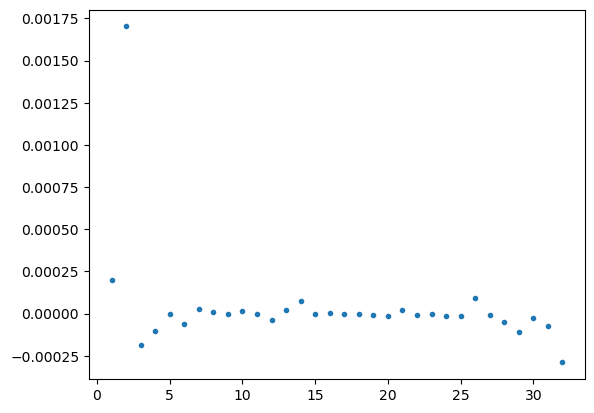

In [389]:
tt = np.linspace(1,32,32)
fig, ax = plt.subplots()
#ax.plot(tt,arr_fsel_D[0,1,:,0],marker='.',ls='')
#ax.plot(tt,arr_psel_vac[1,1,:],marker='.',ls='')
#ax.plot(tt,arr_fsel_V[1,1,:],marker='.',ls='')

ax.plot(tt,arr_psel_meson[1,8,0,:],marker='.',ls='')
#ax.plot(tt,arr_fsel_D[1,1,1,:],marker='.',ls='')

#ax.plot(tt,psel_meson_tsep2[0],marker='.',ls='')
#ax.plot(tt,fsel_meson_tsep[0],marker='.',ls='')

In [220]:
D = cu.diagrams.construct_full_direct_diagram(arr_fsel_D,isospin=2)

NameError: name 'arr_fsel_D' is not defined

In [761]:
(D_avg[0,1:-1]/psel_avg[0,:-1])

array([1.25642799-1.63757030e-07j, 1.23357234-4.58053851e-07j,
       1.19188391-1.25846922e-07j, 1.18078691-2.27481615e-08j,
       1.18576158-2.30079923e-07j, 1.20226251-8.74751465e-07j,
       1.21724908-1.12691082e-06j, 1.23694473-4.87760601e-07j,
       1.26208324+1.16181683e-08j, 1.25920394-4.74297439e-07j,
       1.24620647-9.57884311e-07j, 1.25519678-1.04324614e-06j,
       1.2345905 -8.43712897e-07j])

In [150]:
#D_jks = jackblocks_all(D,omit=[])
psel_jks = jackblocks_all(arr_psel_pipi,omit=[])

#D_norm = counter_norm(D_jks)
psel_norm = counter_norm(psel_jks)

#D_avg, D_err = jack_all(D_norm.real)
psel_avg,psel_err = jack_all(psel_norm.real)

NameError: name 'D_avg' is not defined

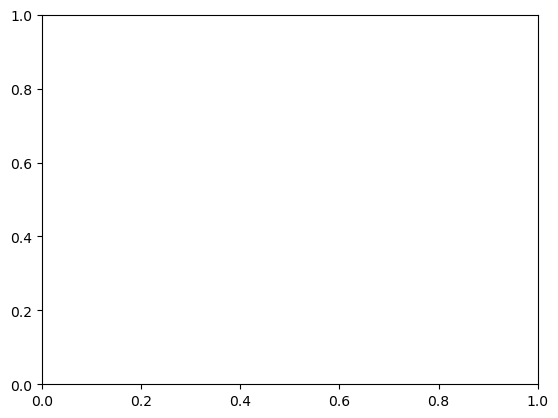

In [218]:
tsep = np.linspace(1,13,13)
fig,ax = plt.subplots()
ax.errorbar(tsep,D_avg[0,1:-1],yerr=D_err[0,1:-1],marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='green',label='Direct, fsel')
ax.errorbar(tsep,psel_avg[0,:-1],yerr=psel_err[0,:-1],marker='s',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Direct, psel')
#ax.errorbar(tsep,psel_avg[1,1:],yerr=psel_err[1,1:],marker='s',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Direct, psel')
ax.set_yscale("log")
ax.legend();

In [721]:
arr_fsel_V.shape

(13, 9, 32)

In [863]:
VC = construct_V(arr_fsel_V[:,0,:].real,arr_fsel_V[:,0,:].real,14,1)
V_gs = construct_V(arr_fsel_V[:,1,:].real,arr_fsel_V[:,1,:].real,14,1)
V_001 = construct_V(arr_fsel_V[:,3,:].real,arr_fsel_V[:,3,:].real,14,1)
V_011 = construct_V(arr_fsel_V[:,5,:].real,arr_fsel_V[:,5,:].real,14,1)
V_111 = construct_V(arr_fsel_V[:,7,:].real,arr_fsel_V[:,7,:].real,14,1)
V = np.stack((VC,V_gs, V_001, V_011, V_111),axis=1)
print(V.shape)

(13, 5, 14)


In [864]:
V_jks = jackblocks_all(V,omit=[])

V_norm = counter_norm(V_jks)

V_avg, V_err = jack_all(V_norm.real)
print(V_avg.shape)

(4, 14)


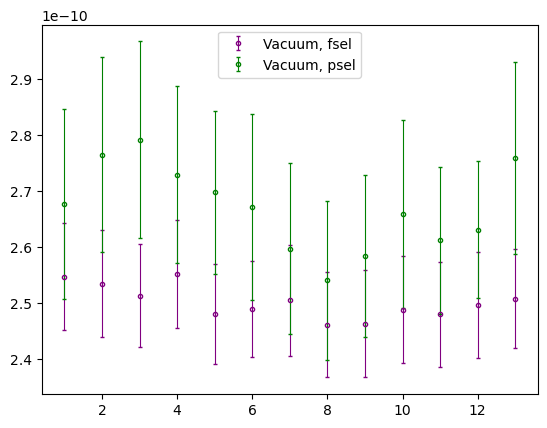

In [865]:
fig,ax = plt.subplots()
ax.errorbar(tsep,V_avg[0,1:],yerr=V_err[0,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Vacuum, fsel')
ax.errorbar(tsep,psel_avg[2,1:].real,yerr=psel_err[2,1:].real,marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='green',label='Vacuum, psel')
#ax.set_ylim(1.5e-10,3.5e-10)
#ax.set_ylim(1.5e6,3.5e6)
ax.legend();

In [77]:
reD_norm_avg[0]/D_norm_avg[0]

array([7.56708827, 4.69693166, 2.86958625, 2.308152  , 2.19108677,
       2.13549601, 2.08879539, 2.00703185, 1.98980165, 1.95577541,
       1.89714014, 1.8050683 , 1.67160769, 1.50315917])

In [222]:
reD_norm_avg[0,1:]/D_norm_avg[1,:]

array([1.25034731, 1.2764565 , 1.27684298, 1.28203509, 1.28748106,
       1.28529713, 1.28388258, 1.29056193, 1.29540077, 1.28940378,
       1.28818982, 1.28660592, 1.28631108, 1.28778091])

In [32]:
reD_psel = cu.diagrams.construct_full_direct_diagram(psel_meson_tsep,Delta,t_size, tsep_max=15)

In [33]:
reD_psel.shape

(9, 5, 15)

In [34]:
reD_psel_jks = jackblocks_all(reD_psel,omit=[])
arr_psel_D_jks = jackblocks_all(arr_psel_pipi,omit=[])

psel_reD_norm = counter_norm(reD_psel_jks)
psel_D_norm = counter_norm(arr_psel_D_jks)

reD_norm_avg, reD_norm_err = jack_all(psel_reD_norm.real)
#reD_norm_avg, reD_norm_err = jack_all(reD_psel_jks.real)
D_norm_avg, D_norm_err = jack_all(psel_D_norm.real)
print(reD_norm_avg.shape)
print(D_norm_avg.shape)

(4, 15)
(48, 14)


In [37]:
D_norm_avg[1]/reD_norm_avg[0,1:]

array([0.96535041, 1.00457869, 1.01194915, 1.01966787, 1.02136434,
       1.01690379, 1.01906272, 1.01776111, 1.00616666, 1.01536912,
       1.0480664 , 1.05369454, 1.01931232, 1.01245667])

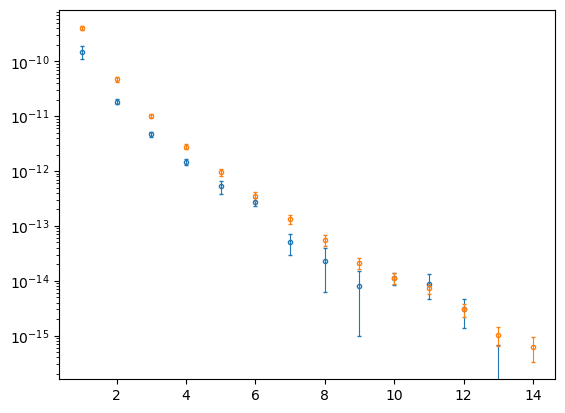

In [38]:
tsep = np.linspace(1,14,14)
fig, ax = plt.subplots()
#ax.errorbar(tsep, D_norm_avg[1,:],yerr=D_norm_err[1,:],marker='.',ls='',elinewidth=0.8,capsize=1.5)
#ax.errorbar(tsep, reD_norm_avg[0,1:],yerr=reD_norm_err[0,1:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)

ax.errorbar(tsep, D_norm_avg[15,:],yerr=D_norm_err[15,:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)
ax.errorbar(tsep, reD_norm_avg[1,1:],yerr=reD_norm_err[1,1:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)

#ax.errorbar(tsep, D_norm_avg[31,:],yerr=D_norm_err[31,:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)
#ax.errorbar(tsep, reD_norm_avg[3,1:],yerr=reD_norm_err[2,1:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)

#ax.errorbar(tsep, D_norm_avg[46,:],yerr=D_norm_err[46,:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)
#ax.errorbar(tsep, reD_norm_avg[3,1:],yerr=reD_norm_err[3,1:],marker='.', markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5)
ax.set_yscale("log")
#ax.legend()

In [287]:
E0_D, E0_D_err = cu.corr_fit.meson_energy_1state(psel_D_norm[:,1,:].real, 2,10)
E0_r, E0_r_err = cu.corr_fit.meson_energy_1state(psel_reD_norm[:,0,:].real, 2,10)

print(f"E0_D: {E0_D} +/- {E0_D_err}")
print(f"E0_r: {E0_r} +/- {E0_r_err}")

Covariance matrix condition number: 2094.289451583122
Covariance matrix condition number: 2748.506203299379
E0_D: 0.4809773427627084 +/- 0.00974272948598664
E0_r: 0.5284658350097177 +/- 0.016950968815850547


In [146]:
VC_psel = cu.diagrams.construct_V(arr_psel_vac[:,0,:].real,arr_psel_vac[:,0,:].real,15,1)
V_gs_psel = cu.diagrams.construct_V(arr_psel_vac[:,1,:].real,arr_psel_vac[:,1,:].real,15,1)
V_001_psel = cu.diagrams.construct_V(arr_psel_vac[:,3,:].real,arr_psel_vac[:,3,:].real,15,1)
V_011_psel = cu.diagrams.construct_V(arr_psel_vac[:,5,:].real,arr_psel_vac[:,5,:].real,15,1)
V_111_psel = cu.diagrams.construct_V(arr_psel_vac[:,7,:].real,arr_psel_vac[:,7,:].real,15,1)
V = np.stack((VC_psel,V_gs_psel, V_001_psel, V_011_psel, V_111_psel),axis=1)
print(V.shape)

(9, 5, 15)


In [147]:
VC_psel[0,1:].shape

(14,)

In [148]:
V_jks = jackblocks_all(V,omit=[])

V_norm = counter_norm(V_jks)

V_avg, V_err = jack_all(V_norm.real)
print(V_avg.shape)

(4, 15)


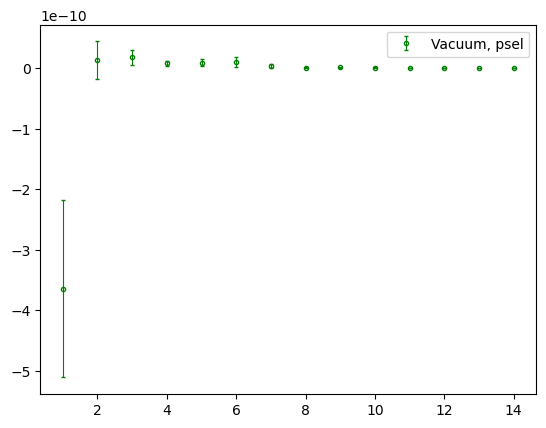

In [154]:
fig,ax = plt.subplots()
#ax.errorbar(tsep,V_avg[0,1:],yerr=V_err[0,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Vacuum, fsel')
ax.errorbar(tsep,psel_avg[4,:].real,yerr=psel_err[4,:].real,marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='green',label='Vacuum, psel')

#ax.errorbar(tsep,V_avg[1,1:],yerr=V_err[1,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Vacuum, fsel')
#ax.errorbar(tsep,psel_avg[17,:].real,yerr=psel_err[17,:].real,marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='green',label='Vacuum, psel')

#ax.errorbar(tsep,V_avg[2,1:],yerr=V_err[2,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Vacuum, fsel')
#ax.errorbar(tsep,psel_avg[32,:].real,yerr=psel_err[32,:].real,marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='green',label='Vacuum, psel')

#ax.errorbar(tsep,V_avg[3,1:],yerr=V_err[3,1:],marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='purple',label='Vacuum, fsel')
#ax.errorbar(tsep,psel_avg[47,:].real,yerr=psel_err[47,:].real,marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,color='green',label='Vacuum, psel')

#ax.set_ylim(1.5e-10,3.5e-10)
#ax.set_ylim(1.5e6,3.5e6)
ax.legend();

In [324]:
V_avg[3,1:] - psel_avg[47,:]

array([ 9.09575556e-24,  1.60266244e-24, -6.24020530e-25, -1.11124122e-23,
       -2.32523378e-24, -5.74058498e-24, -8.21889565e-24, -3.88265978e-24,
       -1.14472426e-23, -6.48173558e-24,  4.32411896e-24,  3.93395467e-25,
       -1.81753553e-25,  6.89694147e-24])

### position space D reconstruction

In [131]:
dst = "/home/jhildebrand28/ktopipi/results/16IH2/auto-contract-pos-test/"
ext_meson_pos = "meson_corr_pos.lat"
ext_psel_pipi = "pipi_corr_psnk_psrc_psel.lat"
ext_meson_mom = "meson_corr_psnk_psrc_psel.lat"
traj_list = list(range(2700,2781,10))

arr_meson_pos = cu.diagrams.load_corr(dst,ext_meson_pos,traj_list)
arr_psel_pipi = cu.diagrams.load_corr(dst,ext_psel_pipi,traj_list)
arr_psel_meson = cu.diagrams.load_corr(dst,ext_meson_mom,traj_list)

array shape: (9, 2, 16, 16, 16, 32)
array shape: (9, 33, 14)
array shape: (9, 2, 32, 32)


In [132]:
importlib.reload(cu.diagrams)

<module 'corr_utils.diagrams' from '/home/jhildebrand28/ktopipi/corr_utils/diagrams.py'>

In [133]:
arr_psel_meson = cu.diagrams.construct_tsep(arr_psel_meson, t_size)
print(arr_psel_meson.shape)

(9, 2, 32)


In [134]:
arr_psel_mom = cu.diagrams.mom_project(arr_meson_pos)
print(arr_psel_mom.shape)

(9, 8, 32)


In [135]:
D_C = cu.diagrams.construct_D(arr_psel_mom[:,0,:],arr_psel_mom[:,0,:],15,1,32)
D_000 = cu.diagrams.construct_D(arr_psel_mom[:,1,:],arr_psel_mom[:,1,:],15,1,32)
D_001 = cu.diagrams.construct_D(arr_psel_mom[:,2,:],arr_psel_mom[:,3,:],15,1,32)
D_011 = cu.diagrams.construct_D(arr_psel_mom[:,4,:],arr_psel_mom[:,5,:],15,1,32)
D_111 = cu.diagrams.construct_D(arr_psel_mom[:,6,:],arr_psel_mom[:,7,:],15,1,32)

D_re = np.stack((D_C, D_000, D_001,D_011, D_111),axis=1)
print(D_re.shape)

(9, 5, 15)


In [136]:
D_jks = jackblocks_all(D_re, omit=[])
pipi_jks = jackblocks_all(arr_psel_pipi, omit=[])

D_norm = counter_norm(D_jks)
pipi_norm = counter_norm(pipi_jks)

D_avg, D_err = jack_all(D_norm.real)
pipi_avg, pipi_err = jack_all(pipi_norm.real)
print(D_avg.shape)

(4, 15)


In [121]:
D_avg[1,1:]/pipi_avg[9]

array([ 2.04023749,  1.10712771,  0.80069895,  1.1184108 ,  1.17293137,
        0.79487042,  0.37212777, -0.5474487 ,  0.3862271 , -0.68686211,
       -0.17373986,  0.35504392,  0.06629194, -0.18270118])

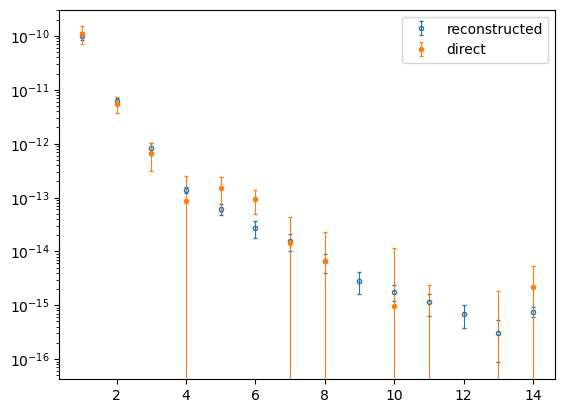

In [143]:
tp = np.linspace(1,14,14)
fig, ax = plt.subplots()
ax.errorbar(tp, D_avg[3,1:], yerr=D_err[3,1:], marker='.',markerfacecolor='none',ls='',elinewidth=0.8,capsize=1.5,label='reconstructed')
ax.errorbar(tp, pipi_avg[30], yerr=pipi_err[30], marker='.',ls='',elinewidth=0.8,capsize=1.5,label='direct')
ax.set_yscale('log')
ax.legend();

### ATW three point function test

In [262]:
dst = '/home/jhildebrand28/ktopipi/results/48I/auto-contract-test/'
ATW_ext = 'pipi_ATW_psnk_psrc.lat'
traj_list = [2115]
arr_ATW = cu.diagrams.load_corr(dst,ATW_ext,traj_list)

array shape: (1, 9, 23)


In [188]:
dst = '/home/jhildebrand28/ktopipi/results/16IH2/auto-contract-ATW-test/'

ATW_ext='pipi_ATW_psnk_psrc.lat'

traj_list = [1050]

arr_ATW = cu.diagrams.load_corr(dst,ATW_ext,traj_list)

array shape: (1, 33, 15)


In [198]:
-arr_ATW[0,2,6:]/arr_ATW[0,1,6:]

array([1.24888775+8.79662564e-04j, 1.33517498+1.03737713e-04j,
       1.3367385 +3.65171448e-04j, 1.36631775+5.38671759e-04j,
       1.36009578-1.21424272e-03j, 1.33957604+1.65561870e-03j,
       1.35715841-3.15065090e-04j, 1.35584965-2.21459763e-04j,
       1.36382477-1.41813563e-04j, 1.3675546 -2.53923422e-04j,
       1.34311929+1.62456524e-03j, 1.35621611-6.28783967e-04j,
       1.3649128 -1.11611466e-04j, 1.33552901+3.74178943e-04j,
       1.32293799+1.13899689e-05j, 1.23208969+1.76018982e-03j])

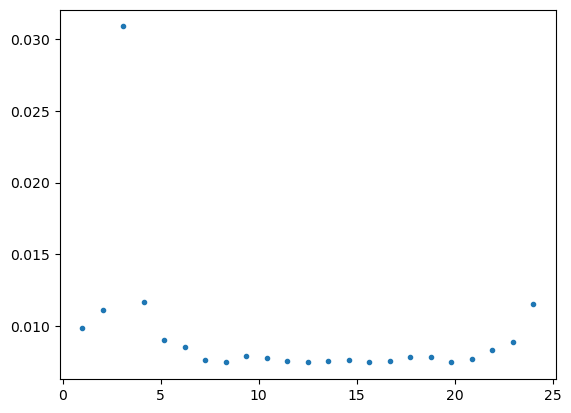

In [263]:
t3 = np.linspace(1,24,23)
fig, ax = plt.subplots()
ax.plot(t3,arr_ATW[0,1,:],marker='.',ls='')
#ax.plot(t3,arr_ATW[0,2,1:],marker='.',ls='')

In [164]:
arr_ATW[0,1,:]

array([-1088631.92123333+0.97492798j,  -752508.43424373-0.01255291j,
        -831558.56258786-0.42908697j,  -652215.14901644+1.0621949j ,
        -617942.15595592-0.16068854j,  -727780.80092641+0.48610128j,
        -547034.13086734+0.98601928j,  -709371.92641761-0.37219169j,
        -638304.13948425-0.24717785j,  -765054.19839443+2.07273869j,
        -641144.92915988+1.34380191j,  -741325.42509359-0.27239177j,
        -677384.55288919-0.35736411j,  -711864.34445393+0.33213944j,
        -941151.21539137+1.66622518j])

In [242]:
dst_meson = '/home/jhildebrand28/ktopipi/results/48I/auto-contract-meson'
dst_pipi = '/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-type'
ext_pipi = 'pipi_corr_psnk_psrc.lat'
ext_meson = 'meson_corr_psnk_psrc_psel.lat'
#traj_list = [1102]
traj_list = list(range(1122,1332,10))

arr_meson = cu.diagrams.load_corr(dst_meson,ext_meson,traj_list)
arr_pipi = cu.diagrams.load_corr(dst_pipi,ext_pipi,traj_list)[:,:,:,0]

array shape: (21, 12, 96)
array shape: (21, 65, 19, 1)


In [243]:
pipi_jks = jackblocks_all(arr_pipi,omit=[])

pipi_norm = counter_norm(pipi_jks)

pipi_avg, pipi_err = jack_all(pipi_norm.real)
print(pipi_avg.shape)

(64, 19)


In [244]:
meson_direct = cu.diagrams.construct_full_direct_diagram(arr_meson, Delta=5,t_size=96,tsep_max=20)
print(meson_direct.shape)

(21, 5, 20)


In [245]:
D_jks = jackblocks_all(meson_direct,omit=[])
D_norm = counter_norm(D_jks)
D_avg, D_err = jack_all(D_norm.real)
print(D_avg.shape)

(4, 20)


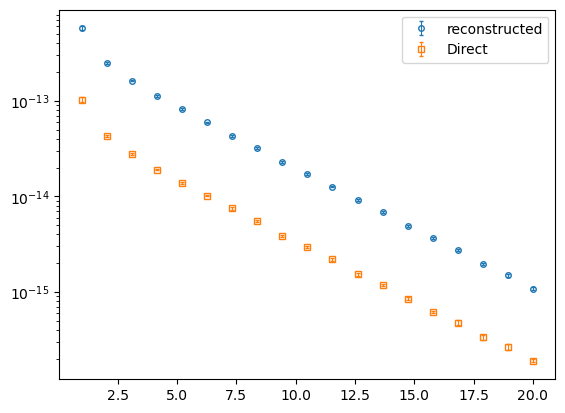

In [255]:
t4 = np.linspace(1,20,19)
fig,ax = plt.subplots()
ax.errorbar(t4, D_avg[1,1:],yerr=D_err[1,1:],marker='o',markerfacecolor='none',markersize=4,ls='',elinewidth=0.8,capsize=1.5,label='reconstructed')
ax.errorbar(t4, pipi_avg[22],yerr=pipi_err[22],marker='s',markerfacecolor='none',markersize=4,ls='',elinewidth=0.8,capsize=1.5, label='Direct')
ax.set_yscale("log")
ax.legend();